# it's cheaper to fly to Paris

Companion notebook to analysis for [TheDraft](https://thedrafthq.substack.com/p/53130b53-f0b2-4f84-937e-e53217582ea0).

## What this is


The promise of live music was a culturally accessible communal experience. This notebook examines what's actually happening to ticket pricing in the US — through dynamic pricing, bot-driven resale markets, and lax regulation — using both aggregated industry data and specific case studies.

Data compiled from Pollstar Year-End Reports, Live Nation Entertainment investor disclosures, the DOJ antitrust filing against Live Nation (May 2024), and contemporary press coverage. EU regulatory data from European Commission and national competition authorities.

## Methodology

Industry-wide ticket price trend data comes from Pollstar's Year-End Business Analyses (annual reports of the Top 100 Tours). 2010–2019 figures are drawn from Pollstar's 2019 historical retrospective chart; 2022–2025 figures come from each year's standalone year-end report.

Case study data is compiled from a combination of personal purchase records, contemporary press coverage, and fan-reported observations across Ticketmaster, SeatGeek, StubHub, and Vivid Seats. Ticketmaster fee ranges come from the company's own fee disclosures, the GAO's 2018 ticketing report, and subsequent journalism.

Regulatory comparison data comes from each jurisdiction's published consumer protection statutes and the US Department of Justice's May 2024 antitrust filing against Live Nation Entertainment. Each price point has a source comment.


In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# style settings for charts later
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

print("setup complete")

setup complete


In [3]:
# step 1A: case study data
# specific concert pricing examples spanning different artist scales and market dynamics
# all prices in USD; EUR converted at ~$1.08 = €1 (2023 rates)

concert_cases = [
    # TAYLOR SWIFT — the founding example, US vs Paris regulatory gap
    {
        "artist": "Taylor Swift",
        "tour": "Eras Tour",
        "year": 2023,
        "market": "US",
        "face_value_low_usd": 2000,
        "face_value_high_usd": 25000,
        "paid_usd": None,  # did not purchase
        "scenario": "Missed presale. Non-presale and resale tickets ranged $2k-$25k via dynamic pricing + bot-driven resale market.",
        "source": "Widely reported (NYT, Vox, Variety)"
    },
    {
        "artist": "Taylor Swift",
        "tour": "Eras Tour",
        "year": 2023,
        "market": "Paris (FR)",
        "face_value_low_usd": 325,  # ~€300 converted
        "face_value_high_usd": 325,
        "paid_usd": 325,
        "scenario": "Carré d'Or VIP (highest tier, included merch box). Plus ~$800 flight = ~$1,125 total trip cost. No lodging (family in Paris).",
        "source": "Personal purchase"
    },

    # SABRINA CARPENTER — mid-tier artist, platinum/dynamic pricing
    {
        "artist": "Sabrina Carpenter",
        "tour": "Short n' Sweet",
        "year": 2024,
        "market": "US (MSG, NYC)",
        "face_value_low_usd": 300,
        "face_value_high_usd": 300,
        "paid_usd": None,  # did not purchase
        "scenario": "$300 face → $430 all-in on Ticketmaster (fees ~$130). Resale on Vivid Seats and similar platforms $350-$400 — LOWER than the Ticketmaster all-in. Platinum pricing active.",
        "source": "Reddit / fan reports across Ticketmaster, Vivid Seats"
    },

    # FREYA SKYE — emerging artist, scalping defeats artist intervention
    {
        "artist": "Freya Skye",
        "tour": "Stars Align (acoustic)",
        "year": 2025,
        "market": "US (NYC)",
        "face_value_low_usd": 50,  # $25 ticket + $25 service fee
        "face_value_high_usd": 50,
        "paid_usd": None,  # did not purchase
        "scenario": "Face value $25 + $25 service fee = $50. Resale $200-$600 on SeatGeek/StubHub despite artist using Ticketmaster Face Value Exchange — New York state law prevented enforcement.",
        "source": "Ticketmaster Face Value Exchange announcement; SeatGeek, StubHub listings"
    },

    # BEYONCÉ — major artist, dynamic pricing reaches even day-of resale
    {
        "artist": "Beyoncé",
        "tour": "Cowboy Carter",
        "year": 2025,
        "market": "US (MetLife, NJ)",
        "face_value_low_usd": 85,
        "face_value_high_usd": 250,
        "paid_usd": 300,  # within day-of resale range of $250-$350
        "scenario": "Section 200 last-minute resale ranged $250-$350. Face value $85-$250 depending on row. Dynamic pricing affected even day-of resale.",
        "source": "Personal purchase; resale platform observation"
    },
]

df_cases = pd.DataFrame(concert_cases)
df_cases

,artist,tour,year,market,face_value_low_usd,face_value_high_usd,paid_usd,scenario,source
0,Taylor Swift,Eras Tour,2023,US,2000,25000,NaN,Missed presale. Non-presale and resale tickets...,"Widely reported (NYT, Vox, Variety)"
1,Taylor Swift,Eras Tour,2023,Paris (FR),325,325,325.0,"Carré d'Or VIP (highest tier, included merch b...",Personal purchase
2,Sabrina Carpenter,Short n' Sweet,2024,"US (MSG, NYC)",300,300,NaN,$300 face → $430 all-in on Ticketmaster (fees ...,"Reddit / fan reports across Ticketmaster, Vivi..."
3,Freya Skye,Stars Align (acoustic),2025,US (NYC),50,50,NaN,Face value $25 + $25 service fee = $50. Resale...,Ticketmaster Face Value Exchange announcement;...
4,Beyoncé,Cowboy Carter,2025,"US (MetLife, NJ)",85,250,300.0,Section 200 last-minute resale ranged $250-$35...,Personal purchase; resale platform observation


In [5]:
# step 2: Pollstar Year-End Top 100 Tours — average North American ticket price
# 2010-2019 data sourced from Pollstar's 2019 Year-End Business Analysis (a historical retrospective chart)
# 2022-2025 data sourced from each year's standalone Pollstar Year-End Business Analysis

pollstar_trend = [
    {"year": 2010, "avg_ticket_usd": 60.77,  "source": "Pollstar 2019 Year-End Business Analysis (historical chart) - https://data.pollstar.com/chart/2019/12/BusinessAnalysis_792.pdf"},
    {"year": 2015, "avg_ticket_usd": 73.86,  "source": "Pollstar 2019 Year-End Business Analysis (historical chart) - https://data.pollstar.com/chart/2019/12/BusinessAnalysis_792.pdf"},
    {"year": 2019, "avg_ticket_usd": 94.83,  "source": "Pollstar 2019 Year-End Business Analysis - https://data.pollstar.com/chart/2019/12/BusinessAnalysis_792.pdf"},
    {"year": 2022, "avg_ticket_usd": 106.07, "source": "https://news.pollstar.com/2022/12/26/https-www-pollstar-com-yearend2022/"},
    {"year": 2023, "avg_ticket_usd": 130.81, "source": "https://news.pollstar.com/2023/12/16/the-great-return-becomes-a-golden-age-2023s-top-tours-see-massive-historic-growth/"},
    {"year": 2024, "avg_ticket_usd": 135.92, "source": "https://news.pollstar.com/2024/12/13/2024bizanalysis/"},
    {"year": 2025, "avg_ticket_usd": 132.62, "source": "https://news.pollstar.com/2025/12/23/year-end-business-analysis-a-return-to-earth-2025-grosses-ticket-sales-drop-averages-increase-beyonce-oasis-coldplay-have-top-tours-venues-stadiums-rock/"},
]

df_trend = pd.DataFrame(pollstar_trend)
df_trend

,year,avg_ticket_usd,source
0,2010,60.77,Pollstar 2019 Year-End Business Analysis (hist...
1,2015,73.86,Pollstar 2019 Year-End Business Analysis (hist...
2,2019,94.83,Pollstar 2019 Year-End Business Analysis - htt...
3,2022,106.07,https://news.pollstar.com/2022/12/26/https-www...
4,2023,130.81,https://news.pollstar.com/2023/12/16/the-great...
5,2024,135.92,https://news.pollstar.com/2024/12/13/2024bizan...
6,2025,132.62,https://news.pollstar.com/2025/12/23/year-end-...


In [6]:
# step 3: Ticketmaster fee structure
# fees stacked on top of face value at checkout
# percentages and amounts vary by show and venue; these are the typical observed ranges
# sourced from Ticketmaster's own fee disclosures, the GAO 2018 ticketing report, and contemporary reporting

ticketmaster_fees = [
    {
        "fee_type": "Service Fee",
        "typical_range_usd": "15-25% of face value",
        "notes": "Largest single fee component. Goes to Ticketmaster.",
        "source": "Ticketmaster fee disclosures; GAO 2018 report on ticketing"
    },
    {
        "fee_type": "Facility/Venue Fee",
        "typical_range_usd": "$5-10 per ticket",
        "notes": "Goes to the venue. Often labeled 'building fee' or 'facility charge'.",
        "source": "Venue contracts; Ticketmaster fee breakdowns"
    },
    {
        "fee_type": "Order Processing Fee",
        "typical_range_usd": "$3-6 per order",
        "notes": "Flat fee per order regardless of ticket count.",
        "source": "Ticketmaster checkout disclosures"
    },
    {
        "fee_type": "Delivery Fee",
        "typical_range_usd": "$0-5",
        "notes": "Variable by delivery method (mobile often free; physical mail charges extra).",
        "source": "Ticketmaster checkout disclosures"
    },
    {
        "fee_type": "Dynamic Pricing Premium ('Platinum')",
        "typical_range_usd": "variable, often 5-20x face value",
        "notes": "Algorithm-set price tier introduced ~2022. Used heavily on Springsteen 2022, Swift 2023, Sabrina Carpenter 2024-25. Not a separate fee — built into the ticket price itself.",
        "source": "NYT, Variety, Billboard coverage 2022-2024"
    },
]

df_fees = pd.DataFrame(ticketmaster_fees)
df_fees

,fee_type,typical_range_usd,notes,source
0,Service Fee,15-25% of face value,Largest single fee component. Goes to Ticketma...,Ticketmaster fee disclosures; GAO 2018 report ...
1,Facility/Venue Fee,$5-10 per ticket,Goes to the venue. Often labeled 'building fee...,Venue contracts; Ticketmaster fee breakdowns
2,Order Processing Fee,$3-6 per order,Flat fee per order regardless of ticket count.,Ticketmaster checkout disclosures
3,Delivery Fee,$0-5,Variable by delivery method (mobile often free...,Ticketmaster checkout disclosures
4,Dynamic Pricing Premium ('Platinum'),"variable, often 5-20x face value",Algorithm-set price tier introduced ~2022. Use...,"NYT, Variety, Billboard coverage 2022-2024"


In [7]:
# step 4: regulatory comparison — US vs EU ticket markets
# qualitative table showing how legal frameworks shape what consumers pay for the same artist on the same tour

regulatory_comparison = [
    {
        "jurisdiction": "United States (Federal)",
        "resale_cap": "None — resale market is unrestricted",
        "bot_legislation": "BOTS Act 2016 (federal) — enforcement is weak; DOJ has prosecuted only a handful of cases since enactment",
        "dynamic_pricing_status": "Legal and standard practice since ~2022",
        "market_concentration": "Live Nation / Ticketmaster controls ~70% of major venue ticketing; DOJ antitrust suit filed May 2024 (joined by 30 state AGs)",
        "notes": "Most permissive ticket market among major economies. State-level protections vary; New York's are notably weak."
    },
    {
        "jurisdiction": "France",
        "resale_cap": "Capped at face value. Loi de 1919, updated 2012 to explicitly cover online resale.",
        "bot_legislation": "Yes — online resale restrictions enforced",
        "dynamic_pricing_status": "Legal but limited by consumer protection laws requiring price transparency",
        "market_concentration": "More fragmented; multiple authorized resellers",
        "notes": "Penalties up to €15,000 (individual) / €75,000 (corporate) for above-face-value sales. Why the Eras Tour Carré d'Or VIP stayed at €300 in Paris while equivalent seats in the US ran $2,000-$25,000."
    },
    {
        "jurisdiction": "United Kingdom",
        "resale_cap": "No hard cap, but Consumer Rights Act 2015 requires resellers to disclose face value, seat/row info, and any restrictions",
        "bot_legislation": "Yes — Digital Economy Act 2018 bans automated bulk buying",
        "dynamic_pricing_status": "Legal but under active scrutiny after Oasis 2024 reunion tour controversy",
        "market_concentration": "Major resale platforms (Viagogo, StubHub) operate but with disclosure requirements",
        "notes": "Post-Oasis 2024 dynamic-pricing backlash triggered Competition and Markets Authority (CMA) investigation into ticketing practices."
    },
    {
        "jurisdiction": "Italy",
        "resale_cap": "Face value. Decreto Anti-Bagarinaggio 2017 explicitly prohibits above-face-value resale.",
        "bot_legislation": "Yes — automated bulk buying restricted",
        "dynamic_pricing_status": "Restricted by consumer protection framework",
        "market_concentration": "Heavily regulated; few major resale platforms operate",
        "notes": "Penalties up to €180,000 for above-face-value sales — strongest enforcement among the European examples."
    },
]

df_regulation = pd.DataFrame(regulatory_comparison)
df_regulation

,jurisdiction,resale_cap,bot_legislation,dynamic_pricing_status,market_concentration,notes
0,United States (Federal),None — resale market is unrestricted,BOTS Act 2016 (federal) — enforcement is weak;...,Legal and standard practice since ~2022,Live Nation / Ticketmaster controls ~70% of ma...,Most permissive ticket market among major econ...
1,France,"Capped at face value. Loi de 1919, updated 201...",Yes — online resale restrictions enforced,Legal but limited by consumer protection laws ...,More fragmented; multiple authorized resellers,"Penalties up to €15,000 (individual) / €75,000..."
2,United Kingdom,"No hard cap, but Consumer Rights Act 2015 requ...",Yes — Digital Economy Act 2018 bans automated ...,Legal but under active scrutiny after Oasis 20...,"Major resale platforms (Viagogo, StubHub) oper...",Post-Oasis 2024 dynamic-pricing backlash trigg...
3,Italy,Face value. Decreto Anti-Bagarinaggio 2017 exp...,Yes — automated bulk buying restricted,Restricted by consumer protection framework,Heavily regulated; few major resale platforms ...,"Penalties up to €180,000 for above-face-value ..."


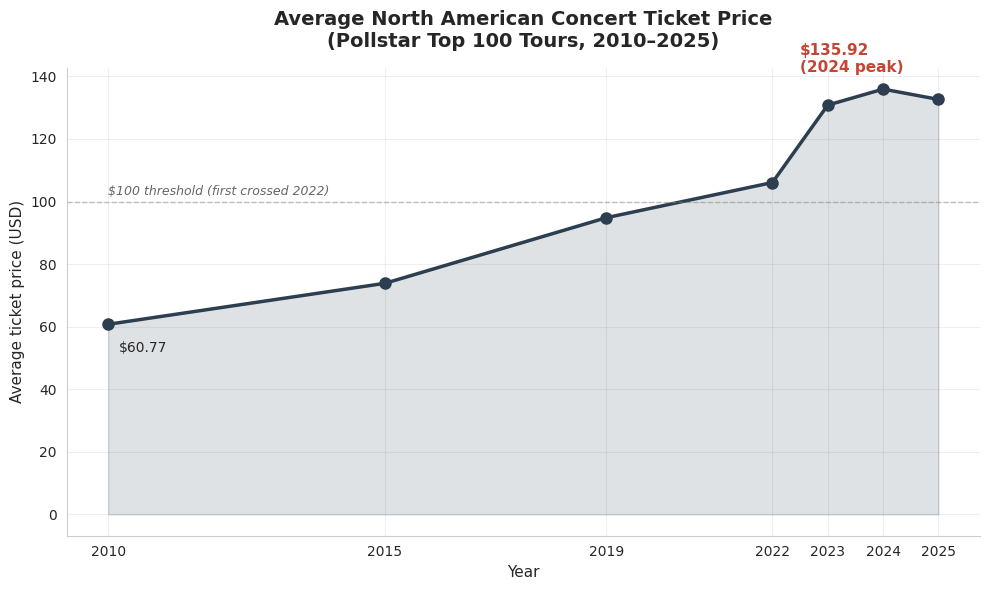

In [8]:
# chart 1: avg North American ticket price 2010-2025
# shows the slow creep and post-pandemic acceleration

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_trend['year'], df_trend['avg_ticket_usd'],
        marker='o', markersize=8, linewidth=2.5, color='#2C3E50')
ax.fill_between(df_trend['year'], df_trend['avg_ticket_usd'],
                alpha=0.15, color='#2C3E50')

# annotate first and peak years
ax.annotate(f"${df_trend['avg_ticket_usd'].iloc[0]:.2f}",
            xy=(df_trend['year'].iloc[0], df_trend['avg_ticket_usd'].iloc[0]),
            xytext=(8, -20), textcoords='offset points', fontsize=10)

# annotate 2024 peak
peak_idx = df_trend['avg_ticket_usd'].idxmax()
ax.annotate(f"${df_trend['avg_ticket_usd'].iloc[peak_idx]:.2f}\n(2024 peak)",
            xy=(df_trend['year'].iloc[peak_idx], df_trend['avg_ticket_usd'].iloc[peak_idx]),
            xytext=(-60, 12), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#C44536')

# the $100 threshold line (first crossed in 2022)
ax.axhline(y=100, color='#888', linestyle='--', linewidth=1, alpha=0.5)
ax.text(2010, 102, '$100 threshold (first crossed 2022)', fontsize=9, color='#666', style='italic')

# styling
ax.set_title('Average North American Concert Ticket Price\n(Pollstar Top 100 Tours, 2010–2025)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average ticket price (USD)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
ax.set_xticks(df_trend['year'])

plt.tight_layout()
plt.savefig('concert_avg_price_over_time.png', bbox_inches='tight', dpi=200)
plt.show()

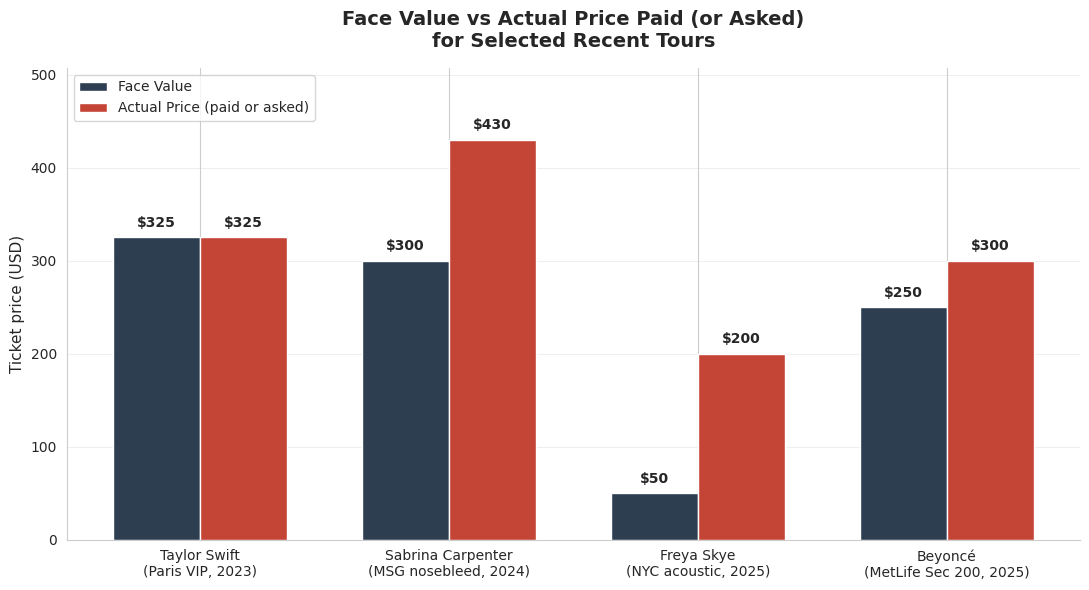

In [9]:
# chart 2: face value vs actual price (paid or asked) for selected recent tours
# Taylor Swift US is excluded for visual scale reasons - its $25k max would dominate the chart
# Paris case acts as the control: face = paid, no markup

case_labels = [
    'Taylor Swift\n(Paris VIP, 2023)',
    'Sabrina Carpenter\n(MSG nosebleed, 2024)',
    'Freya Skye\n(NYC acoustic, 2025)',
    'Beyoncé\n(MetLife Sec 200, 2025)',
]
face_values = [325, 300, 50, 250]
actual_prices = [325, 430, 200, 300]  # for ranges: Freya uses low-end of $200-$600 resale; Beyoncé uses paid

# the figure
fig, ax = plt.subplots(figsize=(11, 6))
x_pos = list(range(len(case_labels)))
width = 0.35

bars1 = ax.bar([x - width/2 for x in x_pos], face_values, width,
               label='Face Value', color='#2C3E50')
bars2 = ax.bar([x + width/2 for x in x_pos], actual_prices, width,
               label='Actual Price (paid or asked)', color='#C44536')

# value labels above each bar
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 8,
            f'${h:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 8,
            f'${h:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# styling
ax.set_xticks(x_pos)
ax.set_xticklabels(case_labels, fontsize=10)
ax.set_ylabel('Ticket price (USD)', fontsize=11)
ax.set_title('Face Value vs Actual Price Paid (or Asked)\nfor Selected Recent Tours',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(actual_prices) * 1.18)

plt.tight_layout()
plt.savefig('concert_face_vs_actual.png', bbox_inches='tight', dpi=200)
plt.show()

## Key findings

**Average concert ticket prices accelerated post-pandemic.** Pollstar Top 100 Tours average ticket price rose from \\$60.77 in 2010 to \\$94.83 in 2019 (\\$34 over nine years, roughly tracking inflation). From 2019 to 2024 the average jumped to \\$135.92, a \\$41 increase in five years — more than double the prior decade's rate. The 2024 peak was the all-time record. 2025 cooled slightly to \\$132.62.

**Ticketmaster fees can exceed resale premiums.** Sabrina Carpenter nosebleeds at Madison Square Garden carried a \$300 face value but cost \$430 all-in via Ticketmaster (~\$130 in fees). Resale prices for the same seats ran \$350–\$400, meaning buying "officially" through Ticketmaster cost more than buying a scalped ticket.

**Even emerging-artist tours are caught in the system.** Freya Skye's NYC acoustic shows had \\$50 all-in face value but resold for \\$200–\$600. The artist's team tried to cap resale using Ticketmaster's Face Value Exchange, but New York State law prevented enforcement of strict resale restrictions.

**The US has the most permissive ticket market among major economies.** France caps resale at face value (Loi de 1919, updated 2012, penalties up to €75,000 corporate). Italy imposes fines up to €180,000 (Decreto Anti-Bagarinaggio). The UK requires resellers to disclose face value (Consumer Rights Act 2015) and banned bots (Digital Economy Act 2018). The US has no federal cap on resale; the BOTS Act of 2016 has been rarely enforced.

**The DOJ has alleged Live Nation/Ticketmaster controls ~70% of US major venue ticketing.** The antitrust suit was filed in May 2024, joined by 30 state attorneys general. The suit is still pending.

**The Eras Tour was an order of magnitude cheaper in Paris than the US.** Carré d'Or VIP tickets sold for €300 in Paris. The lowest available US tickets after the presale window started at \\$2,000 and topped \$25,000. A round-trip flight from the US to Paris was cheaper than the cheapest US ticket.

## Limitations

- Pricing reflects US/North American and selected European markets only.
- Case study data includes some fan-reported figures cross-referenced across resale platforms but not from a single canonical source.
- "Average ticket price" from Pollstar Top 100 Tours skews toward stadium and arena shows; club venue averages are lower (~\$40–$50) and not analyzed here.
- The Live Nation antitrust suit is unresolved.

## Charts

- `concert_avg_price_over_time.png` — line chart of average North American ticket prices, 2010–2025
- `concert_face_vs_actual.png` — bar chart comparing face value to actual price paid/asked for selected tours

## Sources

See dataset `source` columns for citations on individual data points. Key sources include:
- Pollstar Year-End Business Analyses (2019, 2022, 2023, 2024, 2025)
- US Department of Justice antitrust filing against Live Nation (May 2024)
- Loi de 1919 (France), Consumer Rights Act 2015 (UK), Decreto Anti-Bagarinaggio (Italy)
- Ticketmaster Face Value Exchange documentation
- Contemporary coverage from NYT, Variety, Billboard, Pollstar News

See the [accompanying post on TheDraft](https://thedrafthq.substack.com) for the full argument.